# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [1]:
# Cell 1: Import libraries and load the dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv", encoding="latin1")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Cell 2: Clean the dataset and create the features we want to study

# Remove mostly empty extra columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()

# Target feature
# We will try to predict whether a title is a Movie or a TV Show
df = df.dropna(subset=["type"])

# Parse date_added
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["date_added_year"] = df["date_added"].dt.year

# Release year stays numeric
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")

# Make a simpler country feature using the first listed country
df["country_main"] = df["country"].fillna("Unknown").str.split(",").str[0].str.strip()

# Keep only the top 10 countries, everything else becomes Other
top_countries = df["country_main"].value_counts().head(10).index
df["country_group"] = df["country_main"].apply(lambda x: x if x in top_countries else "Other")

# Make a simpler genre feature using the first listed genre
df["main_genre"] = df["listed_in"].fillna("Unknown").str.split(",").str[0].str.strip()

# Keep only the top 10 genres, everything else becomes Other
top_genres = df["main_genre"].value_counts().head(10).index
df["genre_group"] = df["main_genre"].apply(lambda x: x if x in top_genres else "Other")

# Fill missing ratings
df["rating"] = df["rating"].fillna("Unknown")

# Convert duration into a number
# Movies are in minutes, TV Shows are in seasons
df["duration_num"] = df["duration"].str.extract("(\d+)").astype(float)

# Create release decade for an easier graph
df["release_decade"] = (df["release_year"] // 10) * 10

# Keep only the columns we need
cols = ["type", "rating", "country_group", "genre_group", "release_year",
        "release_decade", "date_added_year", "duration_num"]
data = df[cols].dropna(subset=["release_year", "duration_num"])

data.head()

,type,rating,country_group,genre_group,release_year,release_decade,date_added_year,duration_num
0,Movie,PG-13,United States,Documentaries,2020,2020,2021.0,90.0
1,TV Show,TV-MA,Other,International TV Shows,2021,2020,2021.0,2.0
2,TV Show,TV-MA,Unknown,Crime TV Shows,2021,2020,2021.0,1.0
3,TV Show,TV-MA,Unknown,Other,2021,2020,2021.0,1.0
4,TV Show,TV-MA,India,International TV Shows,2021,2020,2021.0,2.0


## Dataset Description

For this lab, I used the **Netflix Titles** dataset. This dataset has information about movies and TV shows on Netflix. It has thousands of rows, so it easily meets the requirement of having a few hundred rows. I picked this dataset because it has a lot of different features that can be compared to one target feature.

The **target feature** I chose is **type**. The target feature tells whether a title is a **Movie** or a **TV Show**.

The 5 features I chose to compare to the target are:

- **rating**  
- **country_group**  
- **genre_group**  
- **release_decade**  
- **duration_num**  

I also made one extra graph for **date_added_year** because it helped show another pattern in the dataset.
    ## Features and Their Values

Here are the features I used and the values they can have:

### Target Feature
- **type**: `Movie`, `TV Show`

### Feature 1
- **rating**: values such as `TV-MA`, `TV-14`, `R`, `PG-13`, `PG`, `TV-PG`, `TV-Y`, `TV-Y7`, `G`, `NR`, `NC-17`, `UR`, `Unknown`, and sometimes a few rare others

### Feature 2
- **country_group**: `United States`, `India`, `United Kingdom`, `Japan`, `South Korea`, `Canada`, `France`, `Spain`, `Mexico`, `Unknown`, and `Other`

### Feature 3
- **genre_group**: `Dramas`, `Comedies`, `Action & Adventure`, `Documentaries`, `Children & Family Movies`, `Crime TV Shows`, `International TV Shows`, `Kids' TV`, `Horror Movies`, `Stand-Up Comedy`, and `Other`

### Feature 4
- **release_decade**: values such as `1940`, `1950`, `1960`, `1970`, `1980`, `1990`, `2000`, `2010`, and `2020`

### Feature 5
- **duration_num**: a number value  
  - for movies, this means **minutes**
  - for TV shows, this means **number of seasons**

### Extra Feature
- **date_added_year**: years such as `2008`, `2009`, `2010`, `2011`, `2012`, `2013`, `2014`, `2015`, `2016`, `2017`, `2018`, `2019`, `2020`, and `2021`

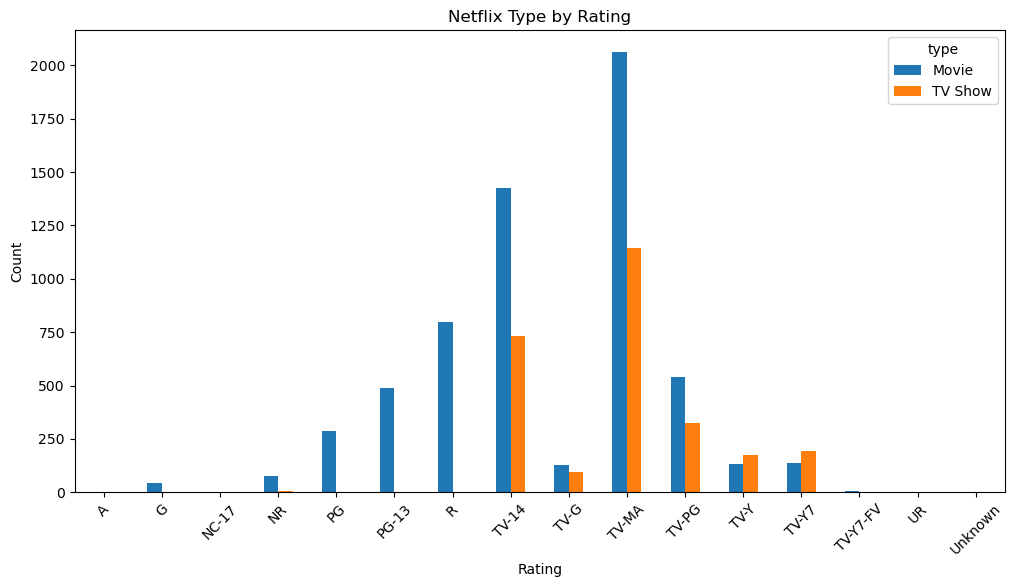

In [3]:
# Cell 4: Relationship 1 - Rating vs Target

rating_type = pd.crosstab(data["rating"], data["type"])

rating_type.plot(kind="bar", figsize=(12, 6))
plt.title("Netflix Type by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 1: Rating vs Type

This graph shows the relationship between **rating** and the target feature, which is **type**. Movies and TV shows both appear a lot in ratings like **TV-MA** and **TV-14**, but movies appear more often in ratings like **PG**, **PG-13**, and **R**.

This tells me that **rating does have a relationship with type**. It is not a perfect way to tell the difference between a movie and a TV show, but it does help because some ratings are clearly more common for one type than the other.

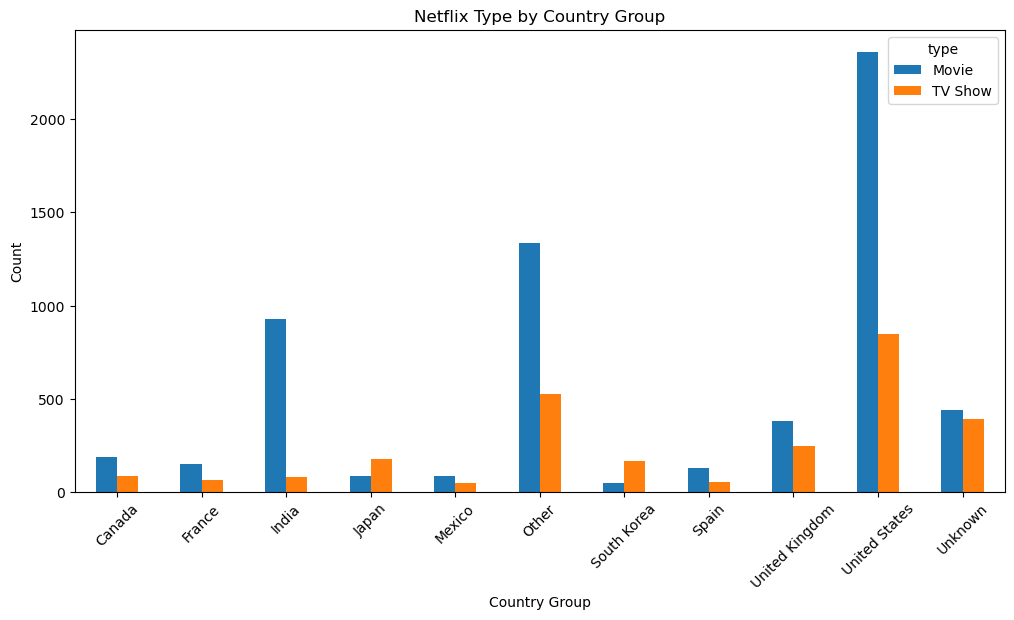

In [4]:
# Cell 6: Relationship 2 - Country vs Target

country_type = pd.crosstab(data["country_group"], data["type"])

country_type.plot(kind="bar", figsize=(12, 6))
plt.title("Netflix Type by Country Group")
plt.xlabel("Country Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 2: Country Group vs Type

This graph compares **country_group** to whether a title is a movie or a TV show. The United States has the most titles overall, and it has many more movies than TV shows. India also has a lot of movies, while countries like Japan and South Korea have more TV shows compared to some other countries.

This means **country has some effect on the target**, but it does not look like the strongest feature. It shows where content is coming from, but by itself it does not fully explain whether something is a movie or a TV show.

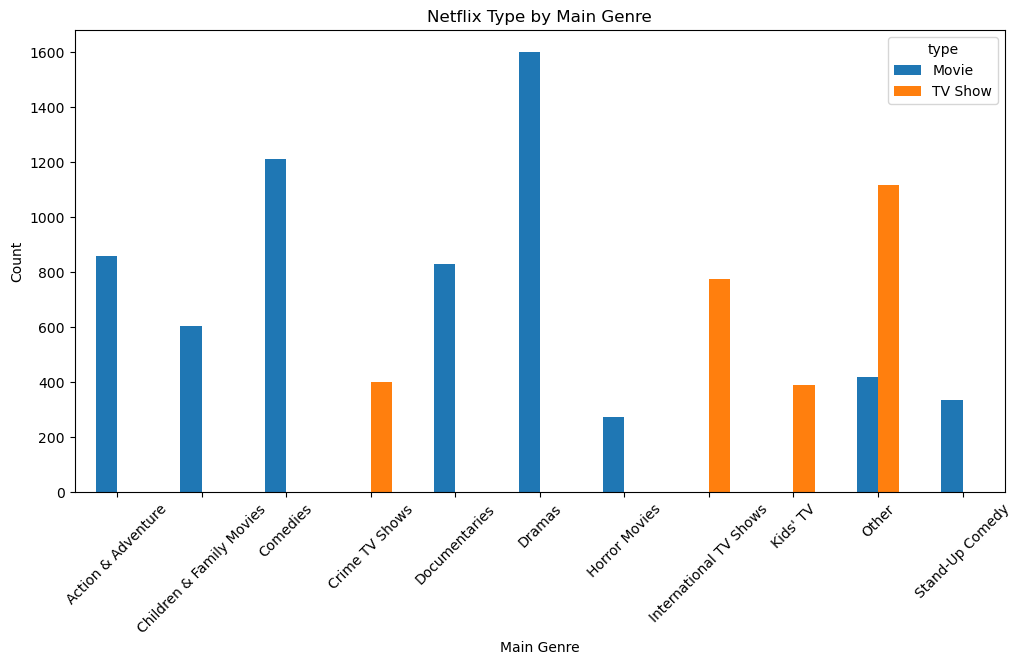

In [5]:
# Cell 8: Relationship 3 - Genre vs Target

genre_type = pd.crosstab(data["genre_group"], data["type"])

genre_type.plot(kind="bar", figsize=(12, 6))
plt.title("Netflix Type by Main Genre")
plt.xlabel("Main Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 3: Main Genre vs Type

This graph shows the relationship between **genre_group** and **type**. Some genres are mostly movies, like **Dramas**, **Comedies**, and **Documentaries**, while other genres are mostly TV shows, like **Crime TV Shows**, **International TV Shows**, and **Kids' TV**.

This makes **genre one of the strongest features** in the dataset. The graph shows a clear difference between movies and TV shows based on the kind of content they are.

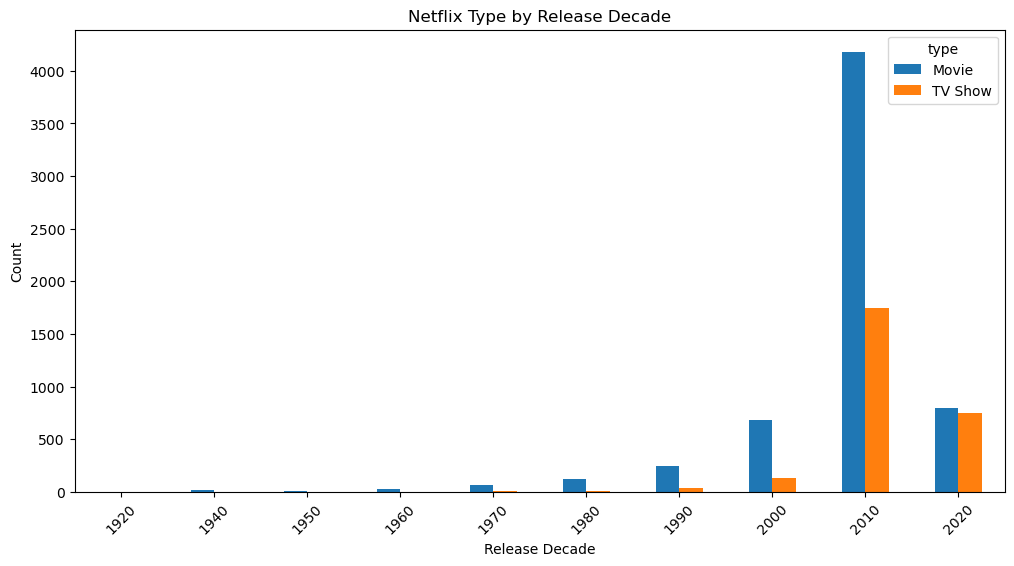

In [6]:
# Cell 10: Relationship 4 - Release Decade vs Target

decade_type = pd.crosstab(data["release_decade"], data["type"])

decade_type.plot(kind="bar", figsize=(12, 6))
plt.title("Netflix Type by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 4: Release Decade vs Type

This graph compares **release_decade** to the target feature. Most of the Netflix titles come from the **2010s** and **2020s**, while much older decades have far fewer titles.

This graph shows that Netflix has a lot more newer content than older content. However, **release decade does not seem to be one of the strongest features** for predicting whether something is a movie or a TV show, because both types appear heavily in the newer decades.

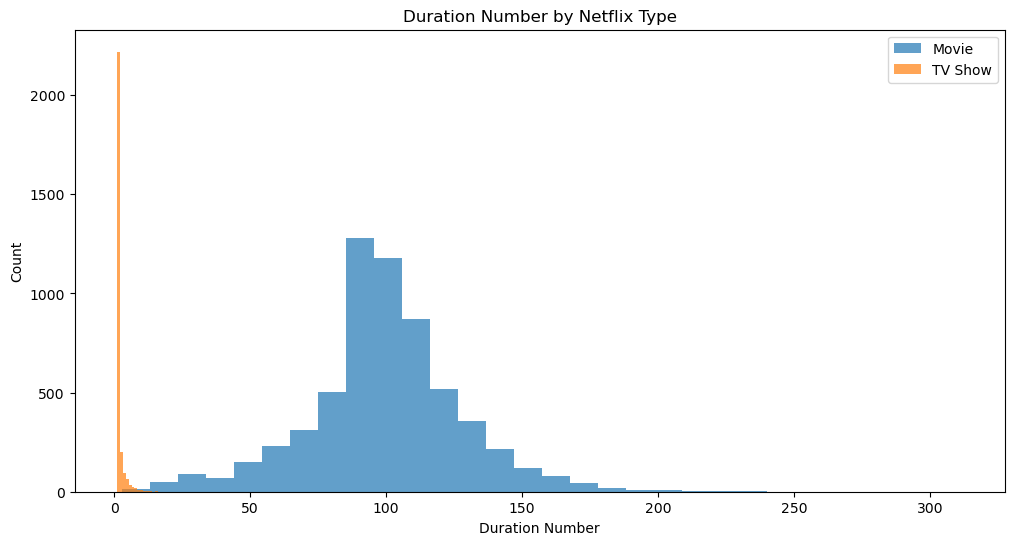

In [7]:
# Cell 12: Relationship 5 - Duration vs Target

movie_duration = data[data["type"] == "Movie"]["duration_num"]
show_duration = data[data["type"] == "TV Show"]["duration_num"]

plt.figure(figsize=(12, 6))
plt.hist(movie_duration, bins=30, alpha=0.7, label="Movie")
plt.hist(show_duration, bins=15, alpha=0.7, label="TV Show")
plt.title("Duration Number by Netflix Type")
plt.xlabel("Duration Number")
plt.ylabel("Count")
plt.legend()
plt.show()

## Visualization 5: Duration Number vs Type

This graph shows one of the clearest relationships in the whole dataset. Movies usually have duration values around normal movie lengths in minutes, while TV shows usually have very small duration values because their duration is counted in seasons.

Because of that, **duration_num looks like the feature most related to the target**. It creates a very clear difference between movies and TV shows and is probably the easiest feature to use to tell them apart.

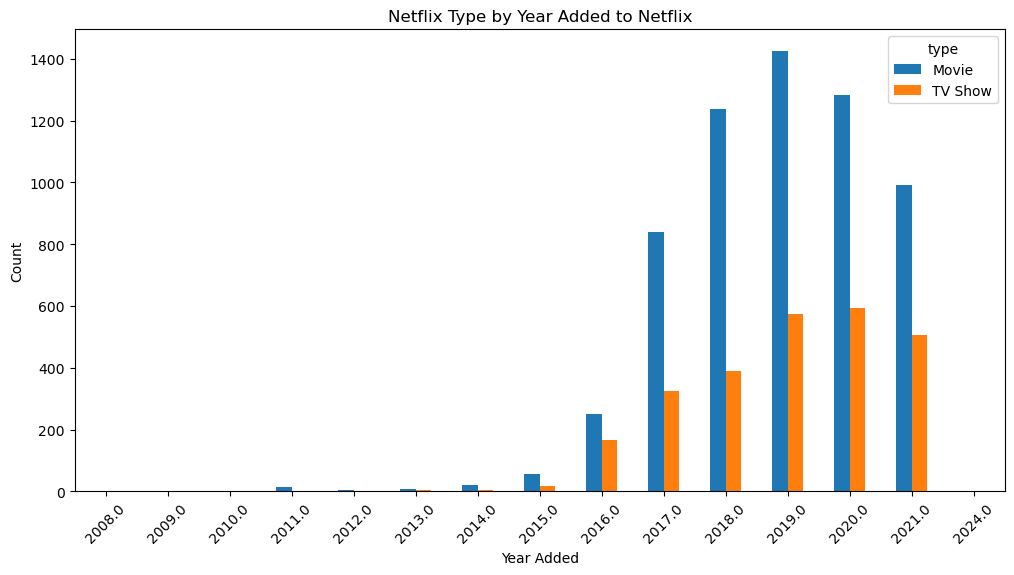

In [8]:
# Cell 14: Relationship 6 - Date Added Year vs Target

added_type = pd.crosstab(data["date_added_year"], data["type"])

added_type.plot(kind="bar", figsize=(12, 6))
plt.title("Netflix Type by Year Added to Netflix")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 6: Year Added to Netflix vs Type

This graph shows how many movies and TV shows were added to Netflix in each year. Both movies and TV shows increase a lot in the later years, especially from 2016 to 2020.

This suggests that Netflix grew a lot during those years. Still, **date_added_year seems more useful for showing Netflix growth over time than for strongly predicting the target feature**.

## Which Features Seem Most Related?

The features that seem most related to the target are **duration_num** and **genre_group**. Duration creates the clearest difference because movies and TV shows measure duration in different ways. Genre is also very important because some genres are mostly movies while others are mostly TV shows.

**Rating** also seems somewhat related because certain ratings appear more often for one type than the other.
## Which Features Do Not Seem to Influence the Target as Much?

The features that seem less related to the target are **release_decade**, **country_group**, and **date_added_year**. These features still show patterns, but they do not separate movies and TV shows as clearly as duration and genre do.

They are useful for understanding the dataset, but they are not the best predictors of the target.
## Big Picture Conclusion

The biggest conclusion from my visualizations is that **movies and TV shows on Netflix are different mostly because of what they are, not just when or where they were made**. Features like **duration** and **genre** matter much more than features like release decade or year added.

Overall, this means the target feature, **type**, is most connected to content-based features. In simple words, the kind of title it is matters more than the time period or country alone.